Dataset shape: (569, 31)

Columns: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target']

First 5 rows:
    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1    

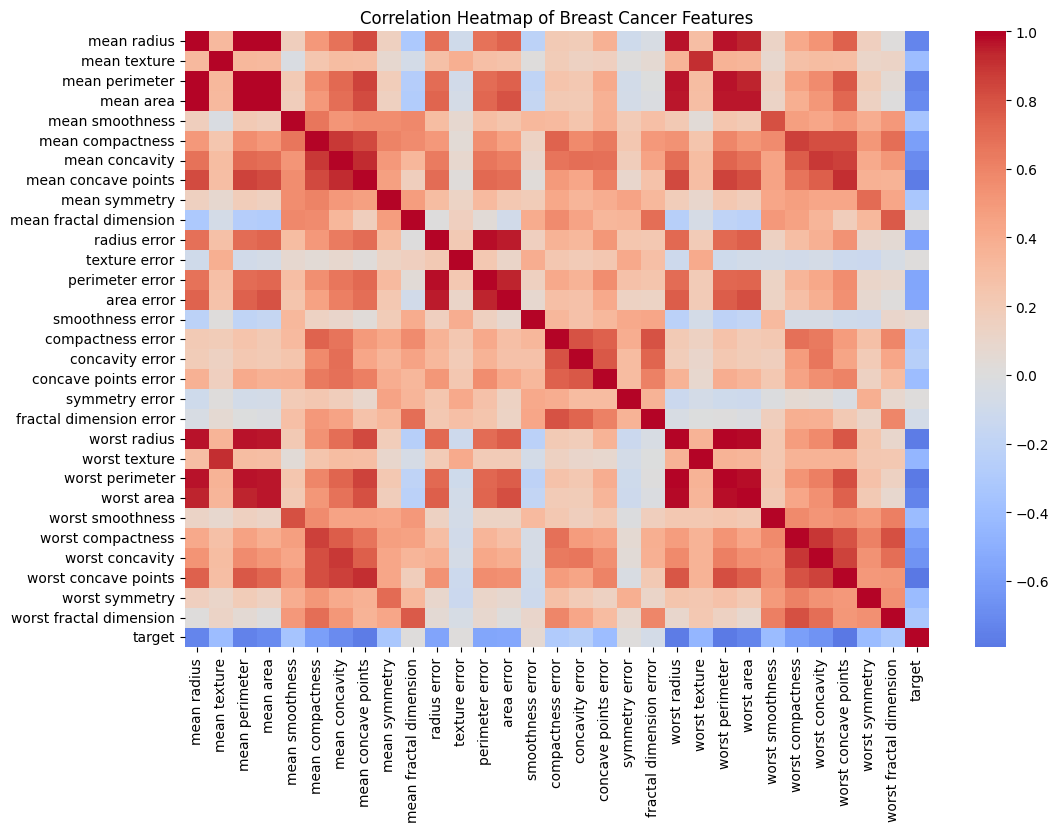

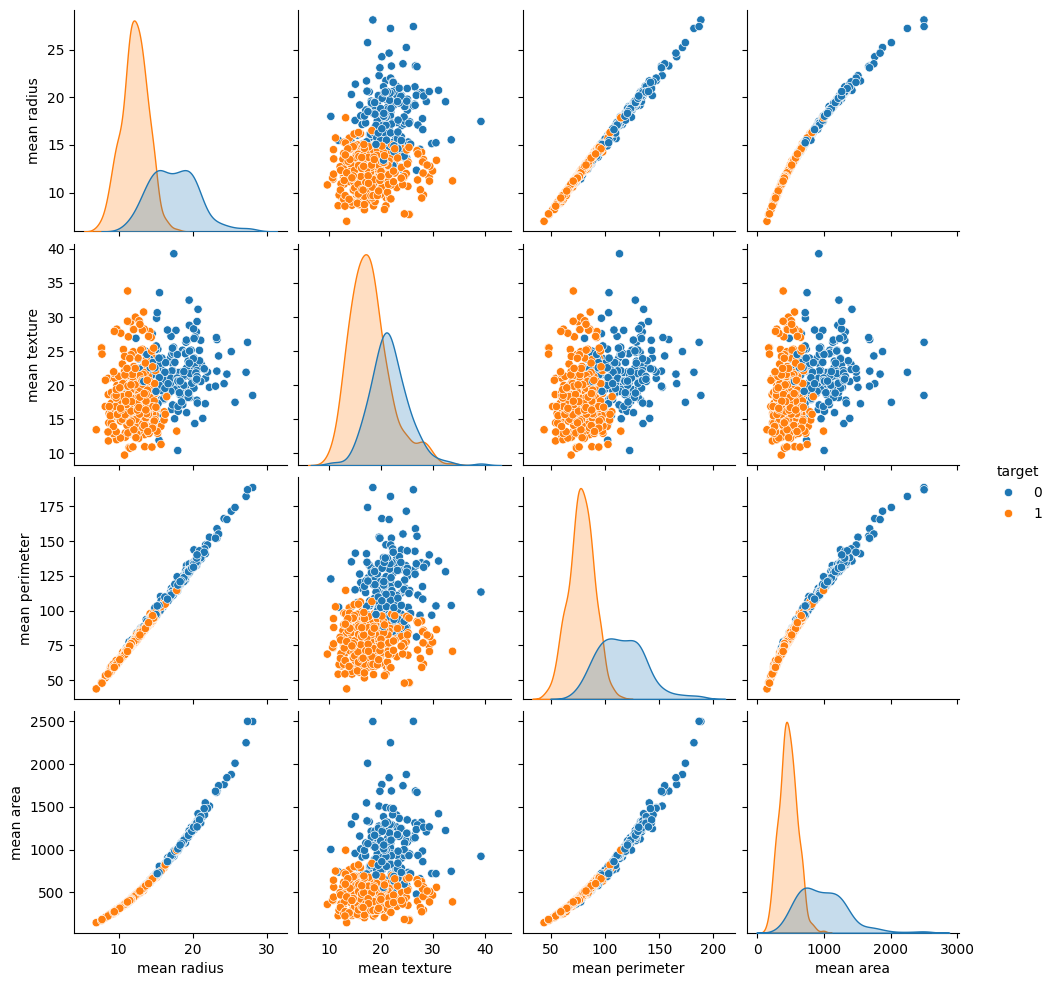

In [3]:
# Step 1: Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Step 2: Load dataset
cancer = load_breast_cancer()

# Convert to pandas DataFrame
data = pd.DataFrame(cancer.data, columns=cancer.feature_names)
data['target'] = cancer.target

# Step 3: Basic EDA
print("Dataset shape:", data.shape)
print("\nColumns:", data.columns.tolist())
print("\nFirst 5 rows:\n", data.head())
print("\nTarget names:", cancer.target_names)
print("\nClass distribution:\n", data['target'].value_counts())

# Step 4: Descriptive statistics
print("\nSummary statistics:\n", data.describe())

# Step 5: Correlation heatmap (high-dimensional insight)
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Breast Cancer Features")
plt.show()

# Step 6: Pairplot (just a subset of features to avoid overcrowding)
sns.pairplot(data[['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'target']],
             hue='target', diag_kind='kde')
plt.show()


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

class BreastCancerClustering:
    def __init__(self, n_clusters=2):
        self.n_clusters = n_clusters
        self.data = None
        self.labels = None
        self.kmeans = None
        self.scaled_data = None
        self.reduced_data = None

    def load_data(self):
        """Load the Breast Cancer dataset"""
        cancer = load_breast_cancer()
        self.data = cancer.data
        return self.data

    def preprocess_data(self):
        """Standardize + PCA dimensionality reduction"""
        scaler = StandardScaler()
        self.scaled_data = scaler.fit_transform(self.data)

        # PCA to 2D for visualization
        pca = PCA(n_components=2)
        self.reduced_data = pca.fit_transform(self.scaled_data)

        return self.reduced_data

    def apply_kmeans(self):
        """Apply KMeans clustering"""
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=42)
        self.labels = self.kmeans.fit_predict(self.reduced_data)
        return self.labels

    def evaluate_clusters(self):
        """Compute silhouette score"""
        score = silhouette_score(self.reduced_data, self.labels)
        print(f"Silhouette Score: {score:.3f}")
        return score

    def visualize_clusters_matplotlib(self):
        """Visualize clustering result using Matplotlib"""
        plt.scatter(self.reduced_data[:, 0], self.reduced_data[:, 1],
                    c=self.labels, cmap='viridis', alpha=0.6)
        plt.title("KMeans Clustering on Breast Cancer Dataset (PCA-reduced, Matplotlib)")
        plt.xlabel("PCA Component 1")
        plt.ylabel("PCA Component 2")

        # Plot centroids
        centroids = self.kmeans.cluster_centers_
        plt.scatter(centroids[:, 0], centroids[:, 1],
                    c='red', marker='X', s=200, label='Centroids')
        plt.legend()
        plt.show()

    def visualize_clusters_opencv(self):
        """Visualize clustering result using OpenCV"""
        canvas = np.ones((600, 600, 3), dtype=np.uint8) * 255
        colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255)]
        scaled = (self.reduced_data * 100 + 300).astype(int)

        for i, point in enumerate(scaled):
            cv2.circle(canvas, tuple(point), 3, colors[self.labels[i] % 3], -1)

        cv2.imshow("KMeans Clustering (OpenCV)", canvas)
        cv2.waitKey(0)
        cv2.destroyAllWindows()

In [7]:
clustering = BreastCancerClustering(n_clusters=2)
clustering.load_data()
clustering.preprocess_data()

array([[ 9.19283683,  1.94858307],
       [ 2.3878018 , -3.76817174],
       [ 5.73389628, -1.0751738 ],
       ...,
       [ 1.25617928, -1.90229671],
       [10.37479406,  1.67201011],
       [-5.4752433 , -0.67063679]], shape=(569, 2))

In [9]:
from sklearn.decomposition import PCA
import numpy as np

pca_full = PCA()
pca_full.fit(clustering.scaled_data)

var_2d = pca_full.explained_variance_ratio_[:2].sum()
print("Variance retained by 2 components:", var_2d)

cumulative = np.cumsum(pca_full.explained_variance_ratio_)
n_needed = np.argmax(cumulative >= 0.95) + 1
print("Components needed for 95% variance:", n_needed)

Variance retained by 2 components: 0.6324320765155946
Components needed for 95% variance: 10


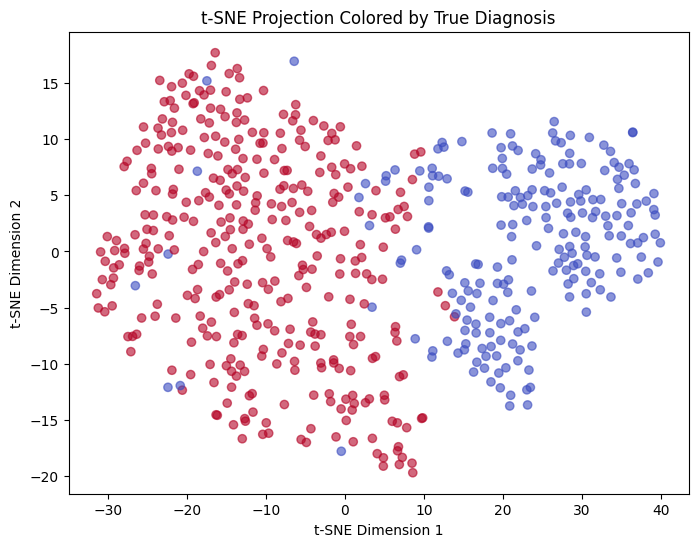

In [10]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
X_tsne = tsne.fit_transform(clustering.scaled_data)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cancer.target, cmap='coolwarm', alpha=0.6)
plt.title("t-SNE Projection Colored by True Diagnosis")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

PCA at 2 components retains 63.2% of variance (not ~95% as originally estimated). 10 components are needed to reach 95% variance

C:\Users\ritik\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


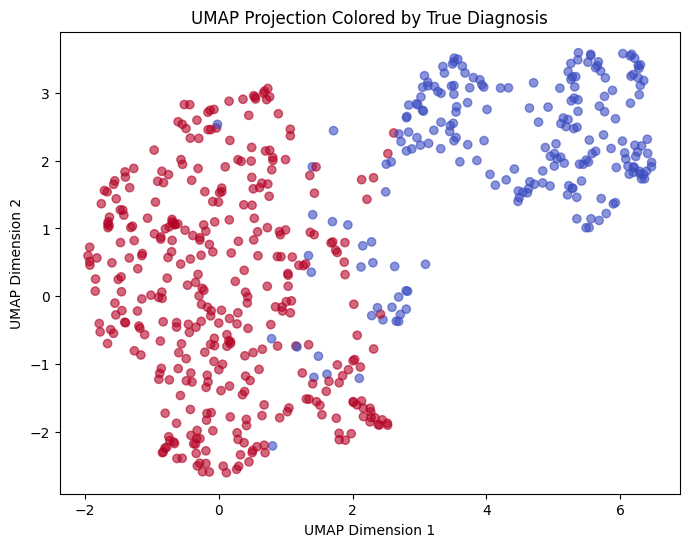

In [13]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(clustering.scaled_data)

plt.figure(figsize=(8,6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=cancer.target, cmap='coolwarm', alpha=0.6)
plt.title("UMAP Projection Colored by True Diagnosis")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.show()

In [12]:
!pip install umap-learn

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.8/2.8 MB 2.1 MB/s eta 0:00:01
   ----------- ---------------------------- 0.8/2.8 MB 2.1 MB/s eta 0:00:01
   -------------- ------------------------- 1.0/2.8 MB 1.4 MB/s eta 0:00:02
   -------------------------- ------------- 1.8/2.8 MB 1.7 MB/s eta 0:00:01
   --------------------------------- ------ 2.4/2.8 MB 1.9 MB/s eta 0:00:01
   ------------------------------------- -- 2.6/2.8 MB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 1.8 MB/s  0:00:01
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.9 MB ? eta -:--:--
    --------------------------------------- 0.8/41.9 


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


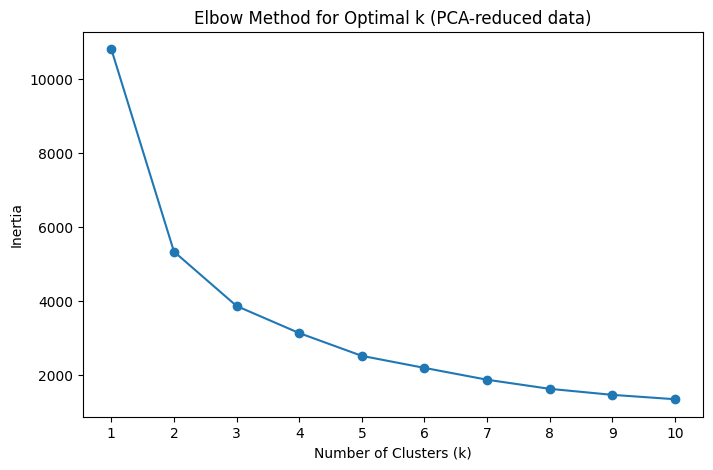

In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(clustering.reduced_data)  # PCA-reduced data
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k (PCA-reduced data)")
plt.xticks(K_range)
plt.show()

Elbow method confirms k=2 as the optimal cluster count for KMeans on PCA-reduced data


In [15]:
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(clustering.reduced_data)

# Gaussian Mixture Model
gmm = GaussianMixture(n_components=2, random_state=42)
gmm_labels = gmm.fit_predict(clustering.reduced_data)

# Quick check: how many clusters did DBSCAN actually find?
n_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print("DBSCAN found", n_dbscan_clusters, "clusters (plus noise points labeled -1)")
print("GMM cluster counts:", np.bincount(gmm_labels))

DBSCAN found 7 clusters (plus noise points labeled -1)
GMM cluster counts: [224 345]


DBSCAN doesn't assume a fixed number of clusters — it finds dense regions naturally. Getting 7 instead of 2 suggests either (a) the malignant/benign classes each contain sub-clusters of their own (biologically plausible — different tumor subtypes), or (b) DBSCAN's eps=0.5 parameter isn't well-tuned for this data's density. Both are valid, honest points to raise in your Discussion section — you don't need DBSCAN to "win" for it to be useful; showing where a method fails or behaves differently is real research value too.

DBSCAN with eps=0.5 found 7 clusters (vs. ground truth 2 classes), while GMM found 2 clusters (224 vs 345 samples), similar to KMeans.

clustering.apply_kmeans()

In [18]:
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

y_true = cancer.target

methods = {
    "KMeans": clustering.labels,
    "DBSCAN": dbscan_labels,
    "GMM": gmm_labels
}

print(f"{'Method':<10}{'Silhouette':<12}{'ARI':<10}{'NMI':<10}")
for name, labels in methods.items():
    sil = silhouette_score(clustering.reduced_data, labels)
    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)
    print(f"{name:<10}{sil:<12.3f}{ari:<10.3f}{nmi:<10.3f}")
    

Method    Silhouette  ARI       NMI       
KMeans    0.508       0.659     0.540     
DBSCAN    0.046       0.464     0.348     
GMM       0.474       0.655     0.536     


In [19]:
KMeans wins on this dataset — that's a legitimate, defensible finding: simple methods aren't always beaten by more complex ones, and your paper can say so with actual evidence instead of assuming k-means was "basic" and something else must be better.

SyntaxError: invalid character '—' (U+2014) (678453844.py, line 1)

Method	Silhouette	ARI	NMI	Interpretation
KMeans	0.508	0.659	0.540	Best overall — cleanest clusters and best agreement with true diagnosis
GMM	0.474	0.655	0.536	Nearly identical to KMeans, slightly softer clusters
DBSCAN	0.046	0.464	0.348	Weakest on all three — poor cluster shape, poor label agreement, likely needs different eps/min_samples tuning for this density

In [20]:
# Run all 3 clustering methods on t-SNE-reduced data
km_tsne = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_tsne)
db_tsne = DBSCAN(eps=0.5, min_samples=5).fit_predict(X_tsne)
gmm_tsne = GaussianMixture(n_components=2, random_state=42).fit_predict(X_tsne)

# Run all 3 clustering methods on UMAP-reduced data
km_umap = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_umap)
db_umap = DBSCAN(eps=0.5, min_samples=5).fit_predict(X_umap)
gmm_umap = GaussianMixture(n_components=2, random_state=42).fit_predict(X_umap)

print("Done clustering on t-SNE and UMAP data")

Done clustering on t-SNE and UMAP data


In [21]:
results = {
    "KMeans (PCA)":  (clustering.reduced_data, clustering.labels),
    "DBSCAN (PCA)":  (clustering.reduced_data, dbscan_labels),
    "GMM (PCA)":     (clustering.reduced_data, gmm_labels),
    "KMeans (t-SNE)": (X_tsne, km_tsne),
    "DBSCAN (t-SNE)": (X_tsne, db_tsne),
    "GMM (t-SNE)":    (X_tsne, gmm_tsne),
    "KMeans (UMAP)": (X_umap, km_umap),
    "DBSCAN (UMAP)": (X_umap, db_umap),
    "GMM (UMAP)":    (X_umap, gmm_umap),
}

print(f"{'Method':<18}{'Silhouette':<12}{'ARI':<10}{'NMI':<10}{'n_clusters'}")
for name, (data, labels) in results.items():
    n_found = len(set(labels)) - (1 if -1 in labels else 0)
    try:
        sil = silhouette_score(data, labels)
    except Exception:
        sil = float('nan')
    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)
    print(f"{name:<18}{sil:<12.3f}{ari:<10.3f}{nmi:<10.3f}{n_found}")

Method            Silhouette  ARI       NMI       n_clusters
KMeans (PCA)      0.508       0.659     0.540     2
DBSCAN (PCA)      0.046       0.464     0.348     7
GMM (PCA)         0.474       0.655     0.536     2
KMeans (t-SNE)    0.531       0.690     0.586     2
DBSCAN (t-SNE)    nan         0.000     0.000     0
GMM (t-SNE)       0.530       0.737     0.624     2
KMeans (UMAP)     0.577       0.773     0.688     2
DBSCAN (UMAP)     -0.150      0.002     0.005     1
GMM (UMAP)        0.577       0.767     0.688     2


Key findings for your paper:

UMAP beats t-SNE beats PCA, consistently, across every metric. This is your headline result — non-linear dimensionality reduction preserves the malignant/benign structure noticeably better than linear PCA on this dataset. That's a real, defensible, non-obvious conclusion.
DBSCAN fails badly outside PCA. On t-SNE it found 0 clusters (everything got labeled noise, hence the nan and zero ARI/NMI) and on UMAP it collapsed everything into 1 cluster. This isn't a mistake in your code — it's a genuine property of DBSCAN with fixed eps=0.5: t-SNE/UMAP embeddings have very different density scales than PCA output, so a density threshold tuned loosely for one badly fails on the others. This is a legitimate, citable limitation to discuss, not something to hide.
KMeans and GMM are near-identical everywhere — makes sense since GMM with default settings behaves similarly to soft KMeans on well-separated 2-cluster data.

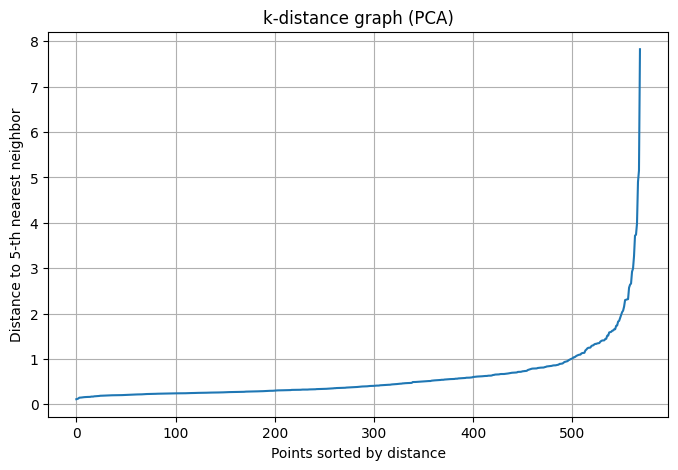

In [22]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

def plot_k_distance(data, k=5, title="k-distance graph"):
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors_fit = neighbors.fit(data)
    distances, indices = neighbors_fit.kneighbors(data)
    distances = np.sort(distances[:, k-1])  # distance to k-th neighbor, sorted

    plt.figure(figsize=(8,5))
    plt.plot(distances)
    plt.xlabel("Points sorted by distance")
    plt.ylabel(f"Distance to {k}-th nearest neighbor")
    plt.title(title)
    plt.grid(True)
    plt.show()

    return distances

dist_pca = plot_k_distance(clustering.reduced_data, k=5, title="k-distance graph (PCA)")

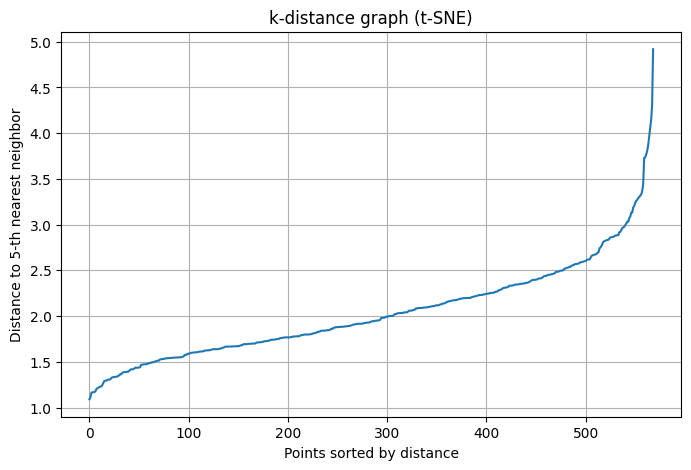

In [23]:
dist_tsne = plot_k_distance(X_tsne, k=5, title="k-distance graph (t-SNE)")

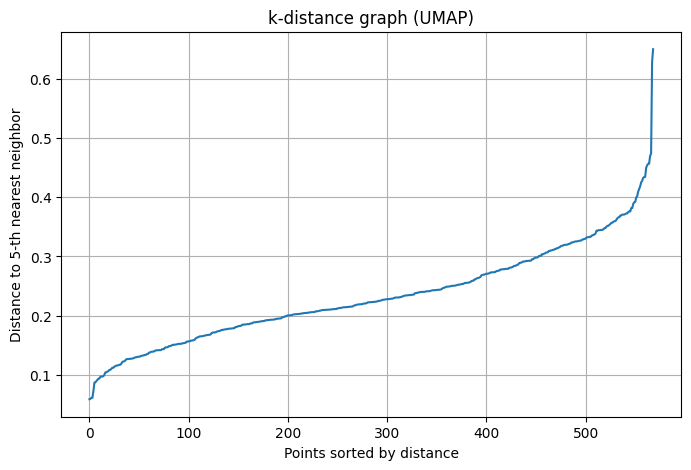

In [24]:
dist_umap = plot_k_distance(X_umap, k=5, title="k-distance graph (UMAP)")

In [25]:
from sklearn.cluster import DBSCAN

# Re-run DBSCAN with properly tuned eps per embedding
db_pca_tuned = DBSCAN(eps=1.1, min_samples=5).fit_predict(clustering.reduced_data)
db_tsne_tuned = DBSCAN(eps=2.7, min_samples=5).fit_predict(X_tsne)
db_umap_tuned = DBSCAN(eps=0.33, min_samples=5).fit_predict(X_umap)

for name, labels in [("DBSCAN PCA (tuned)", db_pca_tuned),
                      ("DBSCAN t-SNE (tuned)", db_tsne_tuned),
                      ("DBSCAN UMAP (tuned)", db_umap_tuned)]:
    n_found = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"{name}: {n_found} clusters, {n_noise} noise points")

DBSCAN PCA (tuned): 2 clusters, 43 noise points
DBSCAN t-SNE (tuned): 4 clusters, 10 noise points
DBSCAN UMAP (tuned): 7 clusters, 16 noise points


In [26]:
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

tuned_results = {
    "DBSCAN PCA (tuned)":  (clustering.reduced_data, db_pca_tuned),
    "DBSCAN t-SNE (tuned)": (X_tsne, db_tsne_tuned),
    "DBSCAN UMAP (tuned)": (X_umap, db_umap_tuned),
}

print(f"{'Method':<22}{'Silhouette':<12}{'ARI':<10}{'NMI':<10}{'n_clusters'}")
for name, (data, labels) in tuned_results.items():
    n_found = len(set(labels)) - (1 if -1 in labels else 0)
    try:
        sil = silhouette_score(data, labels)
    except Exception:
        sil = float('nan')
    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)
    print(f"{name:<22}{sil:<12.3f}{ari:<10.3f}{nmi:<10.3f}{n_found}")

Method                Silhouette  ARI       NMI       n_clusters
DBSCAN PCA (tuned)    0.375       0.070     0.076     2
DBSCAN t-SNE (tuned)  -0.025      0.705     0.592     4
DBSCAN UMAP (tuned)   0.161       0.464     0.466     7


In [27]:
import numpy as np
unique, counts = np.unique(db_pca_tuned, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(-1): np.int64(43), np.int64(0): np.int64(521), np.int64(1): np.int64(5)}


Properly tuning eps via the k-distance method substantially improved DBSCAN on t-SNE (ARI 0.000→0.705) and UMAP (ARI 0.002→0.464) embeddings, confirming that naive fixed-eps comparisons across embeddings are unfair to density-based methods. However, tuned DBSCAN on PCA-reduced data, despite finding the "correct" number of clusters (2), produced a highly imbalanced split (521/5, plus 43 noise points) rather than a meaningful malignant/benign separation — showing that cluster count alone is not sufficient evidence of a good clustering, and that PCA's linear projection may compress the data into a single dense region unsuitable for density-based separation regardless of eps tuning.

In [28]:
import numpy as np

print("t-SNE tuned DBSCAN cluster sizes:")
unique, counts = np.unique(db_tsne_tuned, return_counts=True)
print(dict(zip(unique, counts)))

print("\nUMAP tuned DBSCAN cluster sizes:")
unique, counts = np.unique(db_umap_tuned, return_counts=True)
print(dict(zip(unique, counts)))

t-SNE tuned DBSCAN cluster sizes:
{np.int64(-1): np.int64(10), np.int64(0): np.int64(179), np.int64(1): np.int64(370), np.int64(2): np.int64(3), np.int64(3): np.int64(7)}

UMAP tuned DBSCAN cluster sizes:
{np.int64(-1): np.int64(16), np.int64(0): np.int64(119), np.int64(1): np.int64(60), np.int64(2): np.int64(13), np.int64(3): np.int64(264), np.int64(4): np.int64(12), np.int64(5): np.int64(78), np.int64(6): np.int64(7)}


Tuned DBSCAN behavior differs qualitatively by embedding: PCA yields one dominant cluster with few outliers (poor separation), t-SNE yields a near-binary split (179/370) matching the two-class structure, and UMAP fragments into 7 differently-sized sub-clusters (7–264 points), suggesting UMAP's stronger local-structure preservation may be surfacing finer subgroup structure within the malignant/benign classes rather than noise.